In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
n_qubits = 2
dev = qml.device("default.qubit",wires=n_qubits)

In [3]:

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

# check qml.StatePre
# def state_preparation(a):
#     qml.RY(a[0], wires=0)

#     qml.CNOT(wires=[0, 1])
#     qml.RY(a[1], wires=1)
#     qml.CNOT(wires=[0, 1])
#     qml.RY(a[2], wires=1)

#     qml.PauliX(wires=0)
#     qml.CNOT(wires=[0, 1])
#     qml.RY(a[3], wires=1)
#     qml.CNOT(wires=[0, 1])
#     qml.RY(a[4], wires=1)
#     qml.PauliX(wires=0)

# @qml.transforms.broadcast_expand
@qml.qnode(dev)
def circuit(weights, x):

    wires=[wire for wire in range(n_qubits)]

    qml.StatePrep(x,wires=wires,normalize=True,pad_with=0.1)


    for layer_weights in weights:
        layer(layer_weights)
    

    # return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))
    return qml.expval(qml.PauliZ(0))
    # return qml.expval(qml.PauliZ(0)),qml.expval(qml.PauliZ(1))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    # z1,z2=circuit(weights, x)
    # return (z1*z2) + bias

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            qml.CNOT(wires=[i, j])

    # for wire in range(n_qubits):
    #     qml.Rot(*layer_weights[wire], wires=wire)

    # for i in range(n_qubits):
    #     for j in range(i+1,n_qubits):
    #         qml.CNOT(wires=[j, i])   
    # qml.CNOT(wires=[1, 0])


def cost(weights, bias, X, Y):
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, X)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [4]:

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [5]:
imp=IterativeImputer(random_state=42)
enc=LabelEncoder()
scaler=RobustScaler()
pca=PCA(n_components=np.power(2,n_qubits))
minmaxscaler=MinMaxScaler()

In [6]:
df_train=pd.read_csv('./clean_train_subset.csv')
class_imbalance(data_df=df_train)

y_train=df_train['diagnosis'].values
y_train = np.array(y_train, requires_grad=False)

id=df_train['id']
x_train=df_train.drop(columns=['diagnosis','id'])
x_train.head()

Absolute frequencies of field "diagnosis"
diagnosis
-1    192
 1    115
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.625407
 1    0.374593
Name: proportion, dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,11.04,16.83,70.92000,373.2,0.10770,0.07804,0.03046,0.02480,0.1714,0.06340,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.1067,0.07431,0.2998,0.07881
1,20.48,21.46,132.50000,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,...,24.22,26.17,161.70,1750.0,0.1228,0.2311,0.3158,0.14450,0.2238,0.07127
2,13.44,21.58,85.73715,563.0,0.08162,0.06031,0.03110,0.02031,0.1784,0.05587,...,15.93,30.25,102.50,787.9,0.1094,0.2043,0.2085,0.11120,0.2994,0.07146
3,11.27,15.50,73.38000,392.0,0.08365,0.11140,0.10070,0.02757,0.1810,0.07252,...,12.04,18.93,79.73,450.0,0.1102,0.2809,0.3021,0.08272,0.2157,0.10430
4,17.95,20.01,114.20000,982.0,0.08402,0.06722,0.07293,0.05596,0.2129,0.05025,...,20.58,27.83,129.20,1261.0,0.1072,0.1202,0.2249,0.11850,0.4882,0.06111


In [7]:
x_scaled_train=scaler.fit_transform(x_train)

X_pca = pca.fit_transform(x_scaled_train)

print(pca.explained_variance_ratio_)

[0.4302974  0.20215182 0.09629862 0.06347137]


In [8]:
# Put back into a DataFrame if you want
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3','PC4'])
df_pca['diagnosis'] = y_train
df_pca['id']=id.reset_index(drop=True)

df_pca.head()

,PC1,PC2,PC3,PC4,diagnosis,id
0,-2.722819,0.066572,-0.811687,-0.626080,-1,266
1,3.183510,-3.101602,1.895033,1.480025,1,7
2,-1.951236,-1.671991,-1.063264,0.351915,1,386
3,0.544157,4.572985,1.779838,3.253373,-1,228
4,1.039995,-1.977740,0.109720,-3.089392,1,212


In [9]:
df_pca.to_csv('./pca_datasets/pca4_clean_train_subset.csv',index=False)

In [ ]:
y_pca_train=df_pca['diagnosis']
x_pca_train=df_pca.drop(columns=['diagnosis','id'])
# x_pca_train=x_pca_train.to_numpy()
x_pca_train=np.array(x_pca_train,requires_grad=False)
# x_pca_train=minmaxscaler.fit_transform(x_pca_train)

In [11]:
print(f"First X sample (original)  : {x_pca_train[0]}")

First X sample (original)  : [0.1272023  0.3510412  0.32314054 0.41581999]


In [12]:
features = np.array(x_pca_train, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)

In [13]:
df_val=pd.read_csv('./clean_val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

y_val=df_val['diagnosis'].values

Absolute frequencies of field "diagnosis"
diagnosis
-1    64
 1    38
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627451
 1    0.372549
Name: proportion, dtype: float64


In [14]:
id_val=df_val['id']
x_val=df_val.drop(columns=['diagnosis','id'])
x_val.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,20.59,21.24,137.800000,1320.0,0.10850,0.16440,0.21880,0.11210,0.1848,0.06222,...,23.86,30.76,163.20,1760.0,0.1464,0.3597,0.5179,0.21130,0.2480,0.08780
1,10.25,16.18,66.368754,324.2,0.10610,0.11110,0.06726,0.03965,0.1743,0.07279,...,11.28,20.61,71.53,390.4,0.1402,0.2360,0.1898,0.09744,0.2608,0.09702
2,12.25,17.94,78.270000,460.3,0.08654,0.06679,0.03885,0.02331,0.1970,0.06228,...,13.59,25.22,86.60,564.2,0.1217,0.1788,0.1943,0.08211,0.3113,0.08132
3,10.51,20.19,68.640000,334.2,0.11220,0.13030,0.06476,0.03068,0.1922,0.07782,...,11.16,22.75,72.62,374.4,0.1300,0.2049,0.1295,0.06136,0.2383,0.09026
4,13.96,17.05,91.430000,602.4,0.10960,0.12790,0.09789,0.05246,0.1908,0.06130,...,16.39,22.07,108.10,826.0,0.1512,0.3262,0.3209,0.13740,0.3068,0.07957


In [15]:
x_scaled_val=scaler.transform(x_val)

X_pca_val = pca.transform(x_scaled_val)

print(pca.explained_variance_ratio_)

[0.4302974  0.20215182 0.09629862 0.06347137]


In [16]:
# Put back into a DataFrame
df_pca_val = pd.DataFrame(X_pca_val, columns=['PC1', 'PC2','PC3','PC4'])
df_pca_val['diagnosis'] = y_val
df_pca_val['id']=id_val.reset_index(drop=True)

df_pca_val.head()

,PC1,PC2,PC3,PC4,diagnosis,id
0,4.612918,-1.940879,-0.196539,0.841072,1,45
1,-0.843037,3.406916,0.974180,0.042420,-1,392
2,-2.116673,-0.008398,-0.865467,-0.217053,-1,348
3,-0.912238,3.444641,1.475241,-0.190195,-1,77
4,0.426647,0.161007,-0.846775,-0.219727,1,378


In [17]:
df_pca_val.to_csv('./pca_datasets/pca4_clean_val_subset.csv',index=False)

In [ ]:
y_pca_val=df_pca_val['diagnosis']
x_pca_val=df_pca_val.drop(columns=['diagnosis','id'])
# x_pca_val=x_pca_val.to_numpy()
x_pca_val=np.array(x_pca_val,requires_grad=False)
# x_pca_val=minmaxscaler.transform(x_pca_val)

In [19]:
print(f"First X VAL sample (original)  : {x_pca_val[0]}")

First X VAL sample (original)  : [0.61776586 0.2233713  0.37630716 0.57897928]


In [20]:
features_val = np.array(x_pca_val, requires_grad=False)
y_val = np.array(y_val, requires_grad=False)

In [21]:
df_test=pd.read_csv('./clean_test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
-1    65
 1    38
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631068
 1    0.368932
Name: proportion, dtype: float64


In [22]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.16,18.03,78.29,455.3,0.09087,0.07838,0.02916,0.015270,0.1464,0.06284,...,13.34,27.87,88.83,547.4,0.12080,0.22790,0.162000,0.05690,0.2406,0.07729
1,12.34,26.86,81.15,477.4,0.10340,0.13530,0.11098,0.045620,0.1943,0.06937,...,15.65,39.34,101.70,768.9,0.17850,0.47060,0.442500,0.14590,0.3215,0.12050
2,18.08,21.84,117.40,1024.0,0.07371,0.08642,0.11030,0.057780,0.1770,0.05340,...,19.76,24.70,129.10,1228.0,0.08822,0.19630,0.234055,0.09181,0.2369,0.06558
3,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.048190,0.1879,0.05852,...,16.25,26.19,109.10,809.8,0.13130,0.30300,0.180400,0.14890,0.2962,0.08472
4,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.12850,0.08842,0.043840,0.02381,0.2681,0.07399


In [23]:
x_scaled_test=scaler.transform(x_clean_test)

X_pca_test = pca.transform(x_scaled_test)

print(pca.explained_variance_ratio_)

[0.4302974  0.20215182 0.09629862 0.06347137]


In [24]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.16,18.03,78.29,455.3,0.09087,0.07838,0.02916,0.015270,0.1464,0.06284,...,13.34,27.87,88.83,547.4,0.12080,0.22790,0.162000,0.05690,0.2406,0.07729
1,12.34,26.86,81.15,477.4,0.10340,0.13530,0.11098,0.045620,0.1943,0.06937,...,15.65,39.34,101.70,768.9,0.17850,0.47060,0.442500,0.14590,0.3215,0.12050
2,18.08,21.84,117.40,1024.0,0.07371,0.08642,0.11030,0.057780,0.1770,0.05340,...,19.76,24.70,129.10,1228.0,0.08822,0.19630,0.234055,0.09181,0.2369,0.06558
3,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.048190,0.1879,0.05852,...,16.25,26.19,109.10,809.8,0.13130,0.30300,0.180400,0.14890,0.2962,0.08472
4,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.12850,0.08842,0.043840,0.02381,0.2681,0.07399


In [25]:
df_pca_test = pd.DataFrame(X_pca_test, columns=['PC1', 'PC2','PC3','PC4'])
df_pca_test['diagnosis'] = y_test
df_pca_test['id']=id_test.reset_index(drop=True)

df_pca_test.head()

,PC1,PC2,PC3,PC4,diagnosis,id
0,-2.615597,-0.619083,-0.427842,0.568120,-1,474
1,1.472170,2.479269,-0.680052,-0.444938,1,345
2,2.145992,-1.365657,2.453388,1.433733,1,49
3,-0.422694,-0.726280,-0.944911,0.210228,-1,495
4,-3.630397,0.023767,-0.313148,-0.442415,-1,447


In [26]:
df_pca_test.to_csv('./pca_datasets/pca4_clean_test_subset.csv',index=False)

In [ ]:
y_pca_test=df_pca_test['diagnosis']
x_pca_test=df_pca_test.drop(columns=['diagnosis','id'])
# x_pca_test=x_pca_test.to_numpy()
x_pca_test=np.array(x_pca_test)
# x_pca_test=minmaxscaler.transform(x_pca_test)

In [28]:
features_test = np.array(x_pca_test, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)

In [29]:
# np.random.seed(0)
# num_data = len(y_train)
# num_train = int(0.75 * num_data)
# index = np.random.permutation(range(num_data))

In [30]:
# np.random.seed(0)
# num_data = len(y_train)
# num_train = int(0.75 * num_data)
# index = np.random.permutation(range(num_data))

# num_qubits = 2
# num_layers = 9

# weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
# bias_init = np.array(0.0,requires_grad=False)

# weights_init



# for i in range(1,11):
#     np.random.seed(0)
#     weights_init = 0.01 * np.random.randn(i, 2, 3,requires_grad=True)
#     print(f"For layer {i} the weights are")
#     print(weights_init)
#     print("----------------------")


 Test Set Evaluation achieved at epoch 92 (Number of layers 1):
Accuracy : 0.8058
Precision: 0.8041
Recall   : 0.7696
F1-score : 0.7805

 Test Set Evaluation achieved at epoch 54 (Number of layers 2):
Accuracy : 0.8058
Precision: 0.8041
Recall   : 0.7696
F1-score : 0.7805

 Test Set Evaluation achieved at epoch 133 (Number of layers 3):
Accuracy : 0.8252
Precision: 0.8217
Recall   : 0.7960
F1-score : 0.8053

 Test Set Evaluation achieved at epoch 125 (Number of layers 4):
Accuracy : 0.9223
Precision: 0.9137
Recall   : 0.9221
F1-score : 0.9175

 Test Set Evaluation achieved at epoch 116 (Number of layers 5):
Accuracy : 0.9612
Precision: 0.9710
Recall   : 0.9474
F1-score : 0.9573

 Test Set Evaluation achieved at epoch 87 (Number of layers 6):
Accuracy : 0.9126
Precision: 0.9130
Recall   : 0.8980
F1-score : 0.9045

 Test Set Evaluation achieved at epoch 108 (Number of layers 7):
Accuracy : 0.9029
Precision: 0.8997
Recall   : 0.8903
F1-score : 0.8946

 Test Set Evaluation achieved at epo

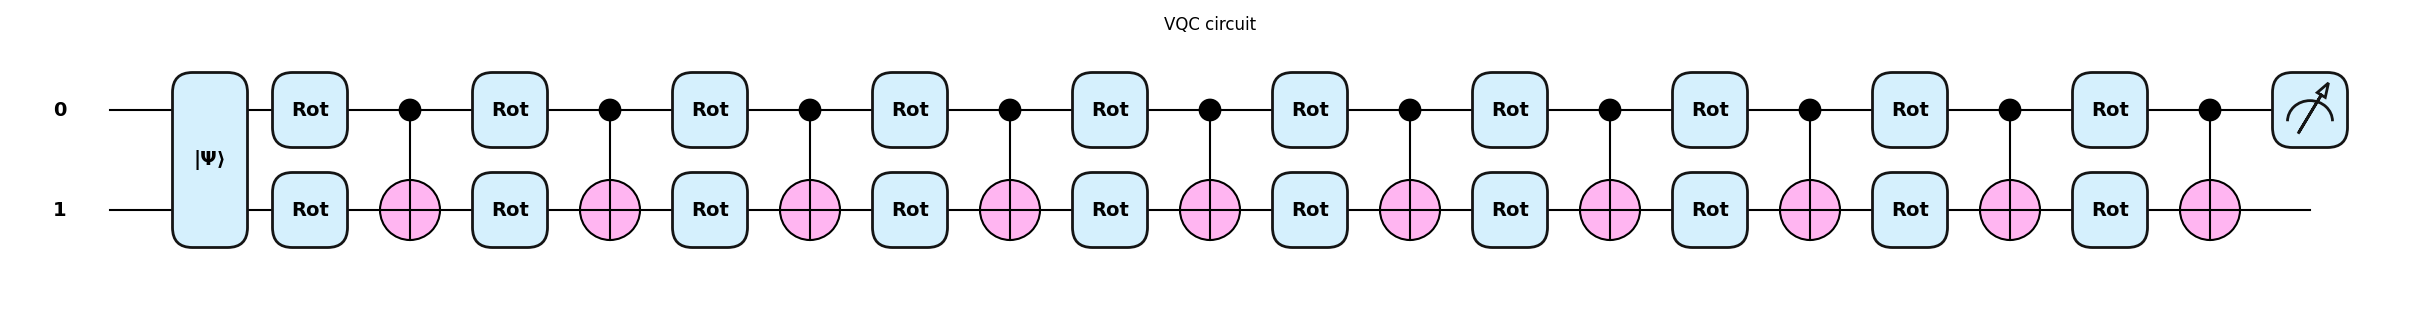

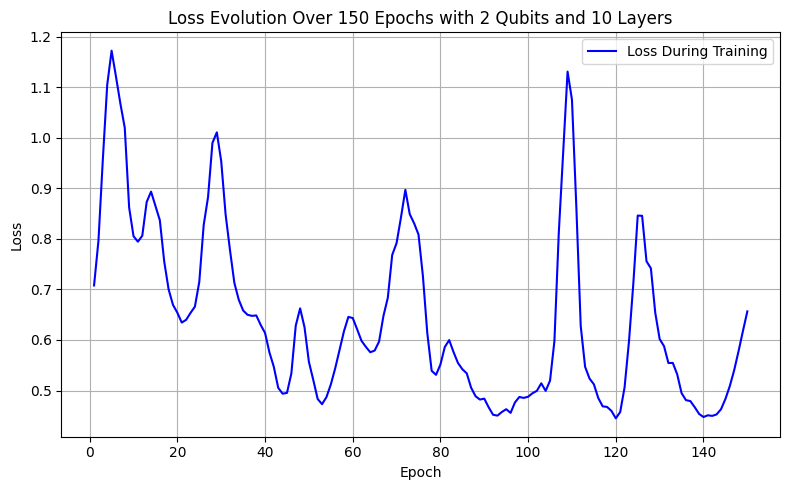

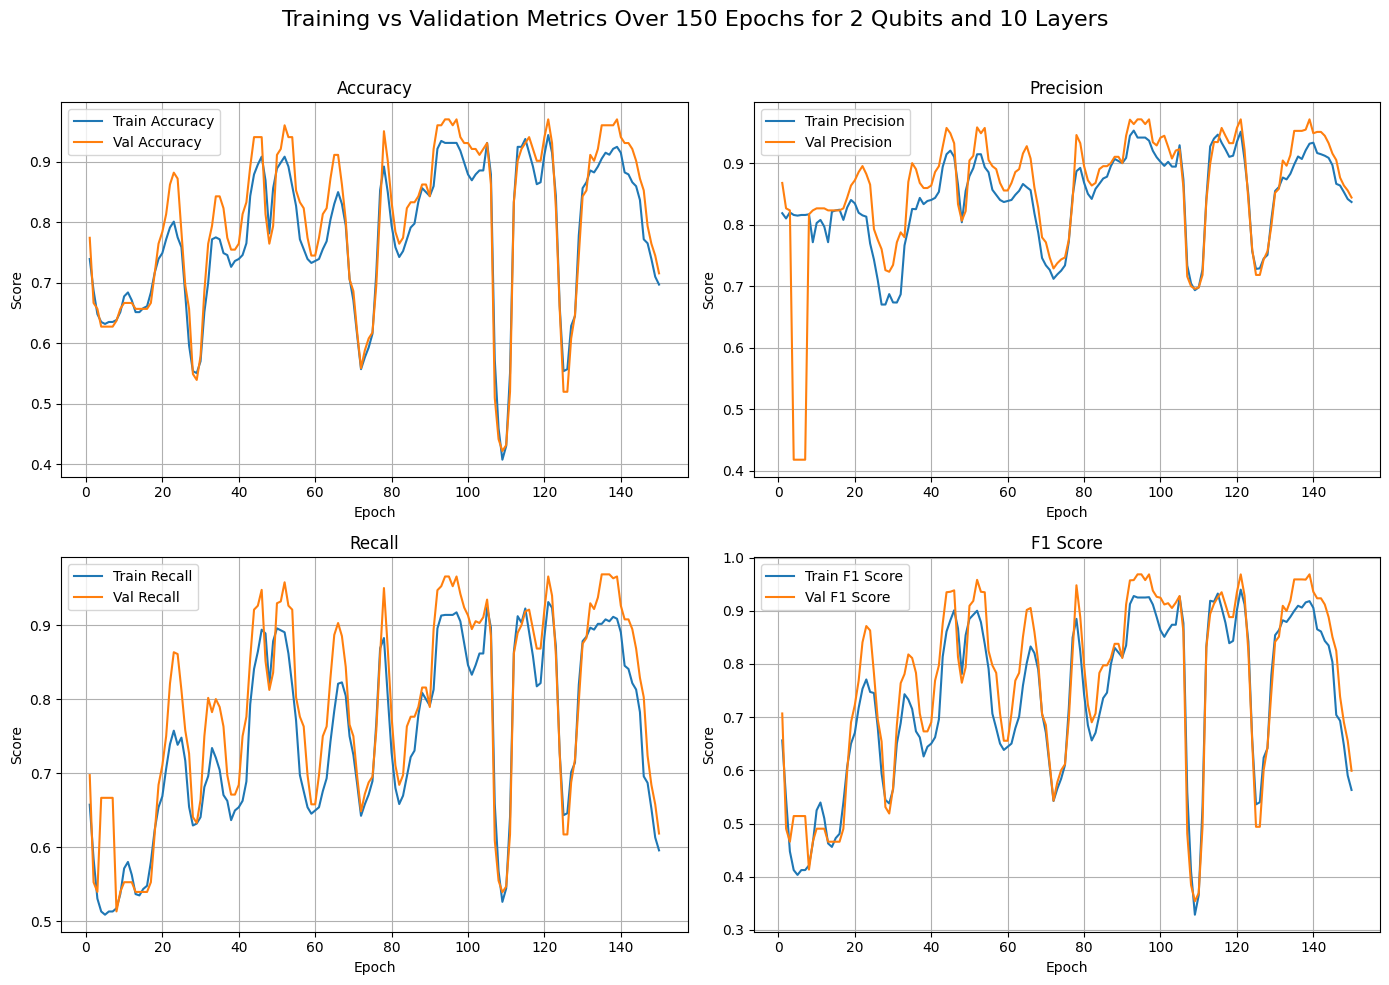

In [31]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 150

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

test_acc=[]
test_prec=[]
test_rec=[]
test_f1=[]

best_epoch=0
biased=False

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 1
    # batch_size = 4


    # Tracking loss
    losses = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        # batch_index = np.random.randint(0, num_train, (batch_size,))
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        losses.append(_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    test_acc.append(acc_test)
    test_prec.append(prec_test)
    test_rec.append(rec_test)
    test_f1.append(f1_test)


    print(f"\n Test Set Evaluation achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias

        best_losses=losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')


print(f"\n--> Test Set Evaluation achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [32]:
# print(f"Best Accuracy {best_accuracy:.4f} for {num_qubits} Qubits can be achieved with {best_layer} Layers")

# plt.figure(figsize=(8, 5))
# plt.plot(layers, test_acc,label='Test Accuracy', linestyle='-', color='blue')
# plt.plot(layers, test_prec,label='Test Precision', linestyle='-', color='orange')
# plt.plot(layers, test_rec,label='Test Recall', linestyle='-', color='green')
# plt.plot(layers, test_f1,label='Test F1', linestyle='-', color='red')
# plt.xlabel("Number of Layers")
# plt.ylabel("Score")
# plt.title(f"Test Metrics Over Number of Layers for {num_qubits} Qubits")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


 Test Set Evaluation for BIASED Classifier achieved at epoch 8 (Number of layers 1):
Accuracy : 0.8058
Precision: 0.7991
Recall   : 0.7751
F1-score : 0.7836

 Test Set Evaluation for BIASED Classifier achieved at epoch 138 (Number of layers 2):
Accuracy : 0.9320
Precision: 0.9420
Recall   : 0.9134
F1-score : 0.9248

 Test Set Evaluation for BIASED Classifier achieved at epoch 132 (Number of layers 3):
Accuracy : 0.9417
Precision: 0.9577
Recall   : 0.9211
F1-score : 0.9351

 Test Set Evaluation for BIASED Classifier achieved at epoch 106 (Number of layers 4):
Accuracy : 0.9612
Precision: 0.9710
Recall   : 0.9474
F1-score : 0.9573

 Test Set Evaluation for BIASED Classifier achieved at epoch 95 (Number of layers 5):
Accuracy : 0.9320
Precision: 0.9514
Recall   : 0.9079
F1-score : 0.9237

 Test Set Evaluation for BIASED Classifier achieved at epoch 92 (Number of layers 6):
Accuracy : 0.9612
Precision: 0.9710
Recall   : 0.9474
F1-score : 0.9573

 Test Set Evaluation for BIASED Classifier 

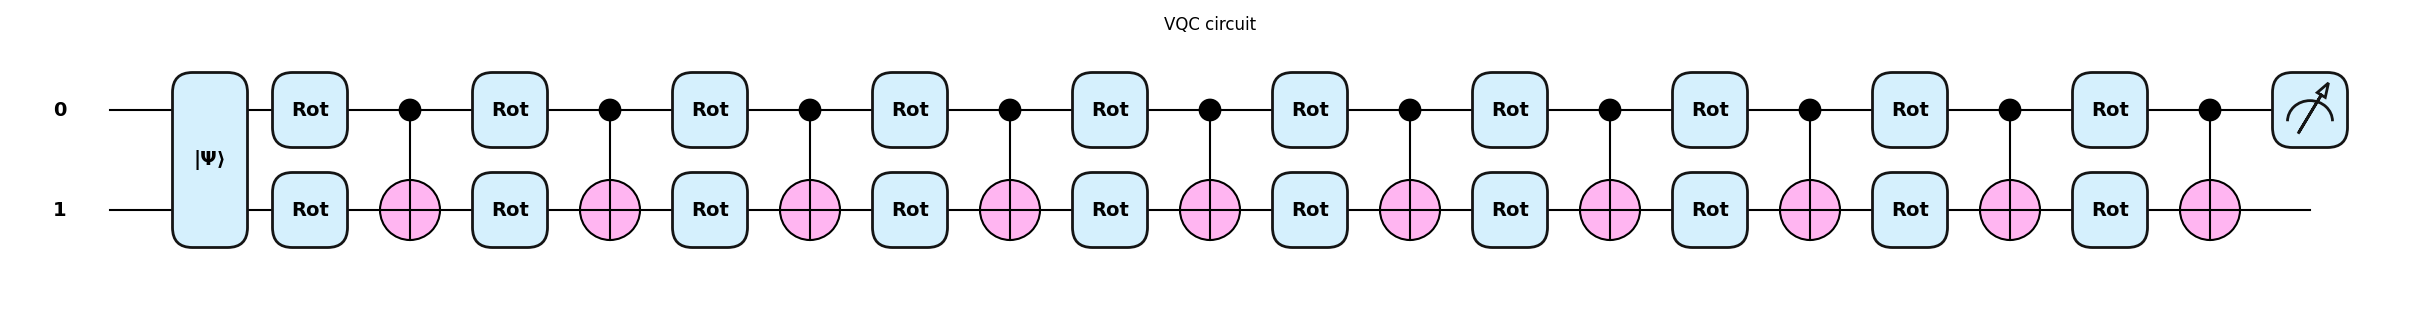

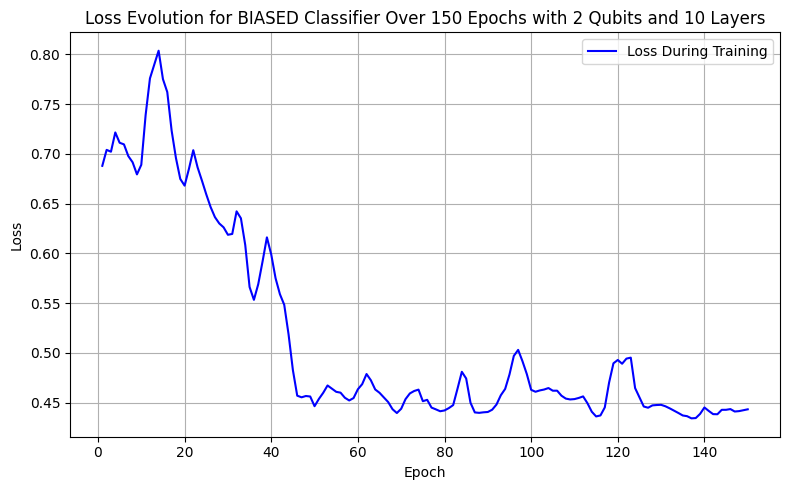

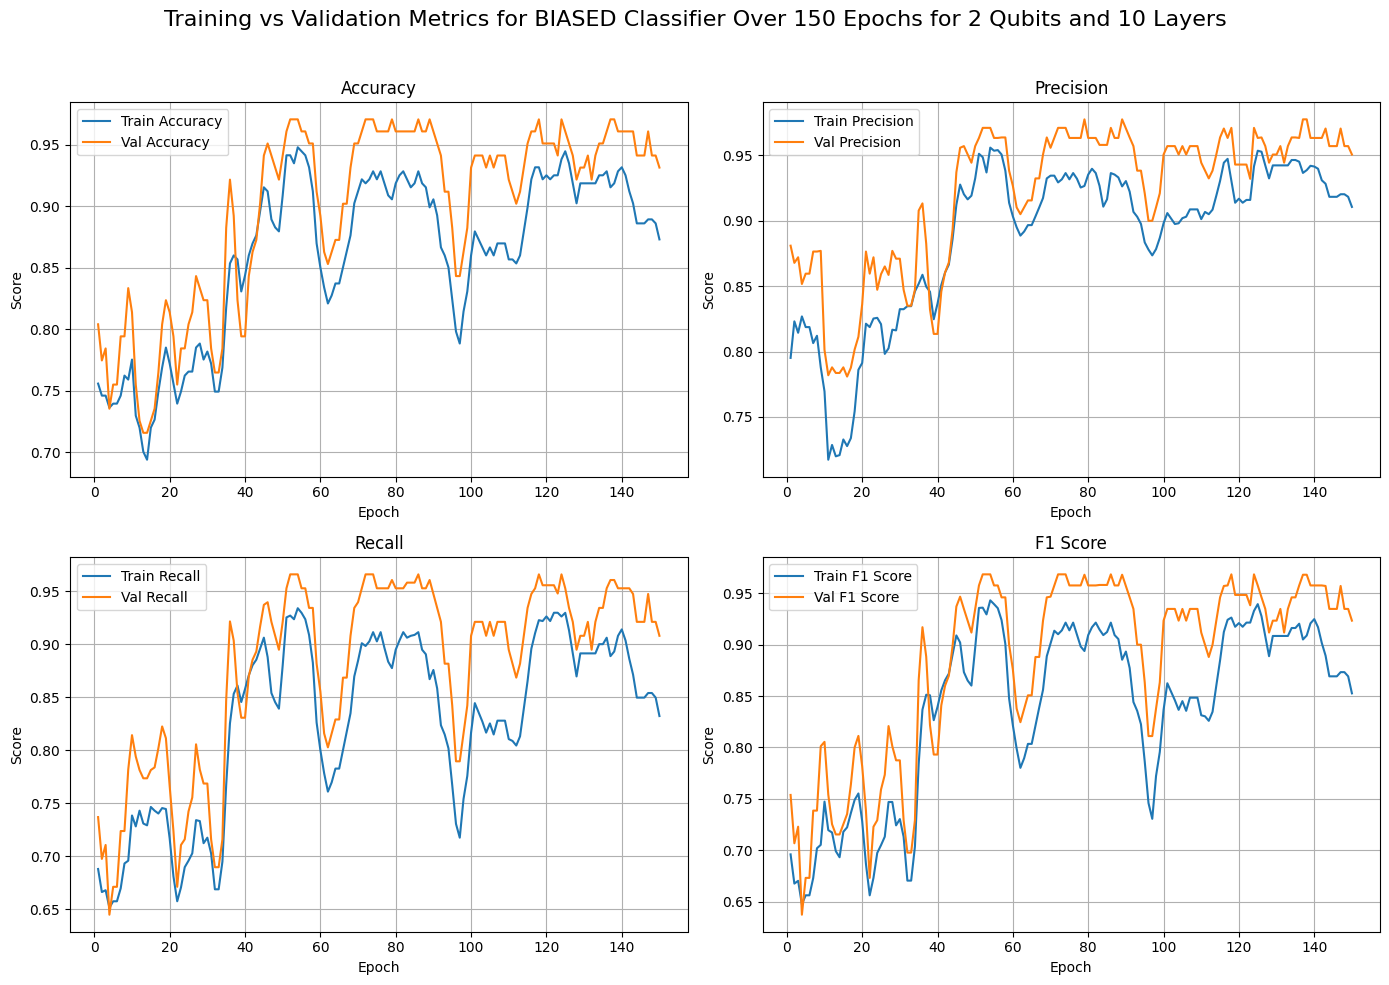

In [33]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 150

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

biased_test_acc=[]
biased_test_prec=[]
biased_test_rec=[]
biased_test_f1=[]

best_epoch=0
biased=True

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5
    # batch_size = 4


    # Tracking loss
    losses = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        # batch_index = np.random.randint(0, num_train, (batch_size,))
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        losses.append(_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    biased_test_acc.append(acc_test)
    biased_test_prec.append(prec_test)
    biased_test_rec.append(rec_test)
    biased_test_f1.append(f1_test)


    print(f"\n Test Set Evaluation for BIASED Classifier achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias.copy()

        best_losses=losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')


print(f"\n--> Test Set Evaluation for BIASED achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution for BIASED Classifier Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics for BIASED Classifier Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your lists are already populated:
# layers, biased_test_acc, test_acc, etc.

# Create a structured DataFrame
data = []
for i, layer in enumerate(layers):
    # Add Biased Data
    data.append({'Layers': layer, 'Score': biased_test_acc[i], 'Metric': 'Accuracy', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_prec[i], 'Metric': 'Precision', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_rec[i], 'Metric': 'Recall', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_f1[i], 'Metric': 'F1', 'Type': 'Biased'})
    
    # Add Unbiased Data
    data.append({'Layers': layer, 'Score': test_acc[i], 'Metric': 'Accuracy', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_prec[i], 'Metric': 'Precision', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_rec[i], 'Metric': 'Recall', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_f1[i], 'Metric': 'F1', 'Type': 'Unbiased'})

df = pd.DataFrame(data)

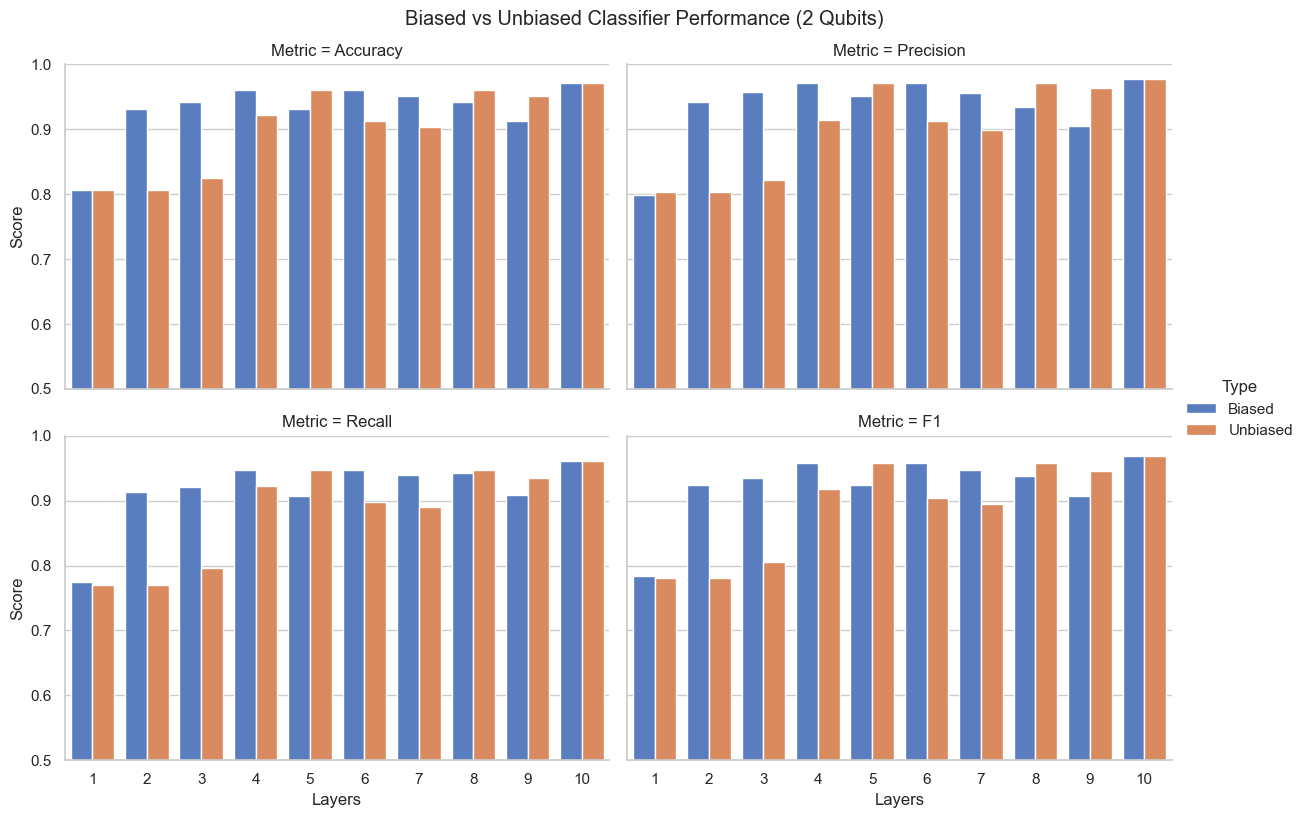

In [35]:
# Set a clean theme
sns.set_theme(style="whitegrid")

# Create the plot
g = sns.catplot(
    data=df, 
    x="Layers", 
    y="Score", 
    hue="Type", 
    col="Metric", 
    kind="bar", 
    col_wrap=2,   # 2 plots per row
    height=4, 
    aspect=1.5,
    palette="muted"
)

# Adjust the Y-axis to focus on the relevant range (optional)
# If you want to see the full 0-1 scale, remove the set_ylim line.
g.set(ylim=(0.5, 1.0)) 

# Add titles
g.figure.suptitle(f'Biased vs Unbiased Classifier Performance ({num_qubits} Qubits)', y=1.02)
plt.show()

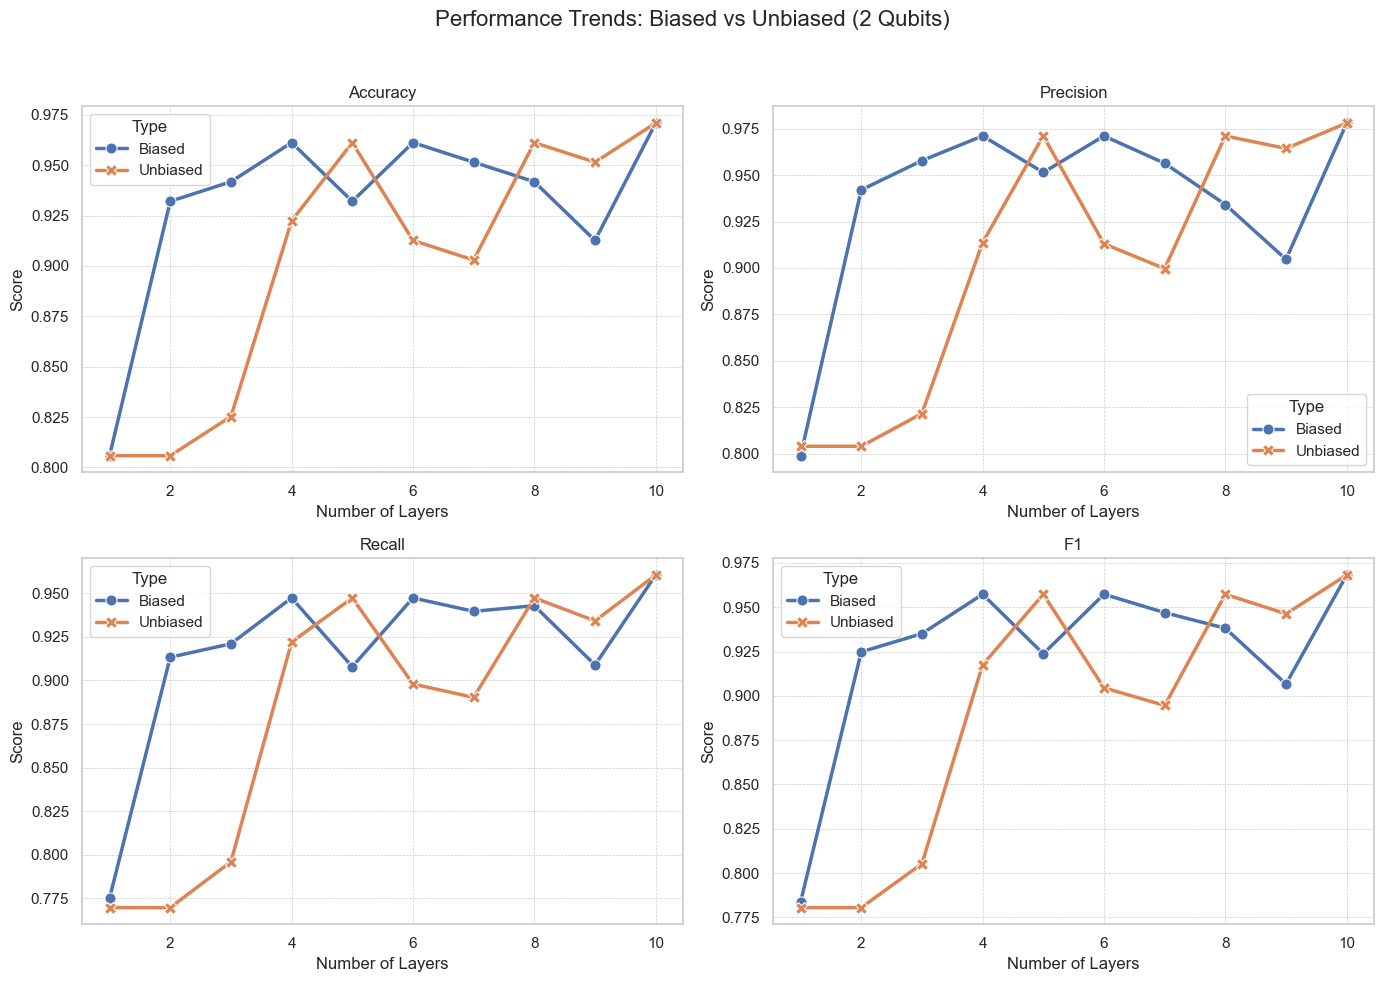

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

# Flatten axes for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Filter data for the specific metric
    subset = df[df['Metric'] == metric]
    
    sns.lineplot(
        data=subset, 
        x="Layers", 
        y="Score", 
        hue="Type", 
        style="Type", 
        markers=True,  # Adds dots at data points
        dashes=False, 
        ax=axes[i],
        linewidth=2.5,
        markersize=8
    )
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Number of Layers")
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.suptitle(f'Performance Trends: Biased vs Unbiased ({num_qubits} Qubits)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

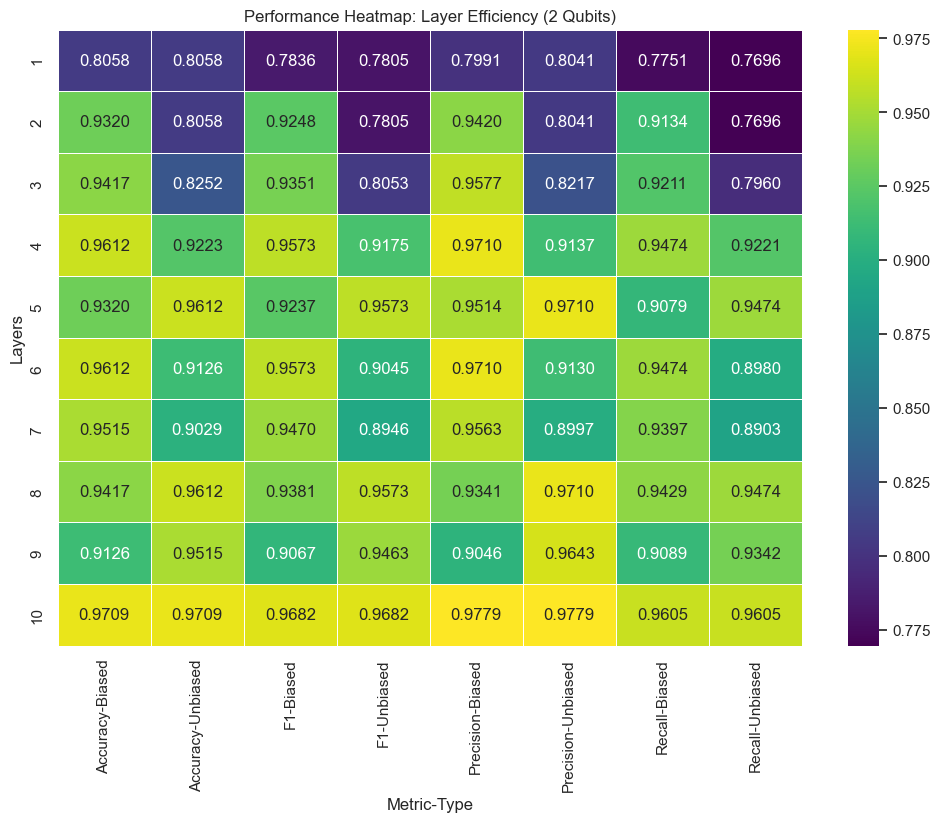

In [37]:
# Pivot data for heatmap: Rows = Layers, Cols = Metric + Type
heatmap_data = df.pivot_table(index="Layers", columns=["Metric", "Type"], values="Score")

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Show the actual numbers
    fmt=".4f",       # 4 decimal places
    cmap="viridis",  # Color scheme
    linewidths=.5
)
plt.title(f"Performance Heatmap: Layer Efficiency ({num_qubits} Qubits)")
plt.show()

In [38]:
# np.random.seed(0)
# num_data = len(y_train)
# num_train = int(0.75 * num_data)
# index = np.random.permutation(range(num_data))

In [39]:
# num_qubits = 2
# num_layers = 2

# weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
# bias_init = np.array(0.0,requires_grad=False)

# weights_init

In [40]:
# opt = NesterovMomentumOptimizer(0.01)
# batch_size = 5
# # batch_size = 4
# num_epochs = 250

# # Tracking loss
# losses = []

# # Tracking Train accuracy
# tr_acc=[]

# # Tracking Validation accuracy
# val_acc=[]

# # Tracking Train precision
# tr_prec=[]

# # Tracking Validation precision
# val_prec=[]

# # Tracking Train recall
# tr_recall=[]

# # Tracking Validation recall
# val_recall=[]

# # Tracking Train F1
# tr_f1=[]

# # Tracking Validation F1
# val_f1=[]

# # Initialize weights
# weights = weights_init
# bias = bias_init
    
# for it in range(num_epochs):
#     # Mini-batch sampling
# # batch_index = np.random.randint(0, num_train, (batch_size,))
#     batch_index = np.random.randint(0, num_data, (batch_size,))
#     feats_train_batch = features[batch_index]
#     Y_train_batch = y_train[batch_index]

#     # Optimizer step
#     # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
#     weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

#     plot=False
#     # Predictions
#     if it==num_epochs-1:
#         plot=True

#     pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
#     pred_val = np.sign(variational_classifier(weights, bias, features_val))

#     # Metrics
#     acc_train = accuracy_score(y_train, pred_train)
#     acc_val = accuracy_score(y_val, pred_val)
#     prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
#     prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
#     rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
#     rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
#     f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
#     f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

#     tr_acc.append(acc_train)
#     val_acc.append(acc_val)
#     tr_prec.append(prec_train)
#     val_prec.append(prec_val)
#     tr_recall.append(rec_train)
#     val_recall.append(rec_val)
#     tr_f1.append(f1_train)
#     val_f1.append(f1_val)

#     # Track loss
#     _cost = cost(weights, bias, features, y_train)
#     losses.append(_cost)

#     if (it + 1) % 2 == 0:
#         print(
#             f"Iter: {it + 1:3d} | Cost: {_cost:0.7f} | "
#             f"Acc Train: {acc_train:0.4f} | Acc Val: {acc_val:0.4f} | "
#             f"Precision: {prec_val:0.4f} | Recall: {rec_val:0.4f} | F1: {f1_val:0.4f}"
#         )
#     # weights=weights_new
#     # bias=bias_new
#     # bias-bias_new

# # After training: evaluate on test set
# pred_test = np.sign(variational_classifier(weights, bias, features_test))

# acc_test = accuracy_score(y_test, pred_test)
# prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
# rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
# f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

# print(f"\n Final Test Set Evaluation (Number of layers {num_layers}):")
# print(f"Accuracy : {acc_test:.4f}")
# print(f"Precision: {prec_test:.4f}")
# print(f"Recall   : {rec_test:.4f}")
# print(f"F1-score : {f1_test:.4f}")

# # Plot loss over time
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, num_epochs + 1), losses, linestyle='-', color='blue')
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title(f"Loss Evolution Over Epochs for {num_qubits} Qubits and {num_layers} Layers")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# epochs_range = range(1, num_epochs + 1)

# plt.figure(figsize=(14, 10))

# # --- Accuracy ---
# plt.subplot(2, 2, 1)
# plt.plot(epochs_range, tr_acc, label='Train Accuracy', linestyle='-')
# plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='-')
# plt.title('Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Precision ---
# plt.subplot(2, 2, 2)
# plt.plot(epochs_range, tr_prec, label='Train Precision', linestyle='-')
# plt.plot(epochs_range, val_prec, label='Val Precision', linestyle='-')
# plt.title('Precision')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Recall ---
# plt.subplot(2, 2, 3)
# plt.plot(epochs_range, tr_recall, label='Train Recall', linestyle='-')
# plt.plot(epochs_range, val_recall, label='Val Recall', linestyle='-')
# plt.title('Recall')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- F1 Score ---
# plt.subplot(2, 2, 4)
# plt.plot(epochs_range, tr_f1, label='Train F1 Score', linestyle='-')
# plt.plot(epochs_range, val_f1, label='Val F1 Score', linestyle='-')
# plt.title('F1 Score')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Layout ---
# plt.suptitle(f'Training vs Validation Metrics Over Epochs for {num_qubits} Qubits and {num_layers} Layers', fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

In [41]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-Score : {metrics_dict['f1']:.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [42]:
# Classical ML method: SVM

svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=svm_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=svm_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=svm_clf)

print("-----> SVM Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> SVM Results <-----

Train Set:
  Accuracy : 0.9413
  Precision: 0.9905
  Recall   : 0.8522
  F1-Score : 0.9146

Validation Set:
  Accuracy : 0.9614
  Precision: 1.0000
  Recall   : 0.8964
  F1-Score : 0.9385

Test Set:
  Accuracy : 0.9810
  Precision: 0.9778
  Recall   : 0.9750
  F1-Score : 0.9749


In [43]:
# Classical ML method: Logistic Regression
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=lr_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=lr_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=lr_clf)

print("-----> Logistic Regression Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Logistic Regression Results <-----

Train Set:
  Accuracy : 0.9217
  Precision: 1.0000
  Recall   : 0.7913
  F1-Score : 0.8812

Validation Set:
  Accuracy : 0.8924
  Precision: 1.0000
  Recall   : 0.7107
  F1-Score : 0.8300

Test Set:
  Accuracy : 0.9614
  Precision: 0.9778
  Recall   : 0.9214
  F1-Score : 0.9443


In [44]:
# Classical ML method: Random Forest
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=forest_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=forest_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=forest_clf)

print("-----> Random Forest Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Random Forest Results <-----

Train Set:
  Accuracy : 0.9286
  Precision: 0.9057
  Recall   : 0.9130
  F1-Score : 0.9066

Validation Set:
  Accuracy : 0.9219
  Precision: 0.9092
  Recall   : 0.8964
  F1-Score : 0.8913

Test Set:
  Accuracy : 0.9514
  Precision: 0.9278
  Recall   : 0.9464
  F1-Score : 0.9345
